In [ ]:
# Import standard libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# Display settings
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
file_path = "datasets/Training_data_uhi_index_UHI2025-v2.csv"
df = pd.read_csv(file_path)
df.head()
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  11229 non-null  float64
 1   Latitude   11229 non-null  float64
 2   datetime   11229 non-null  object 
 3   UHI Index  11229 non-null  float64
dtypes: float64(3), object(1)
memory usage: 351.0+ KB


,Longitude,Latitude,UHI Index
count,11229.000000,11229.000000,11229.000000
mean,-73.933927,40.808800,1.000001
std,0.028253,0.023171,0.016238
min,-73.994457,40.758792,0.956122
25%,-73.955703,40.790905,0.988577
50%,-73.932968,40.810688,1.000237
75%,-73.909647,40.824515,1.011176
max,-73.879458,40.859497,1.046036


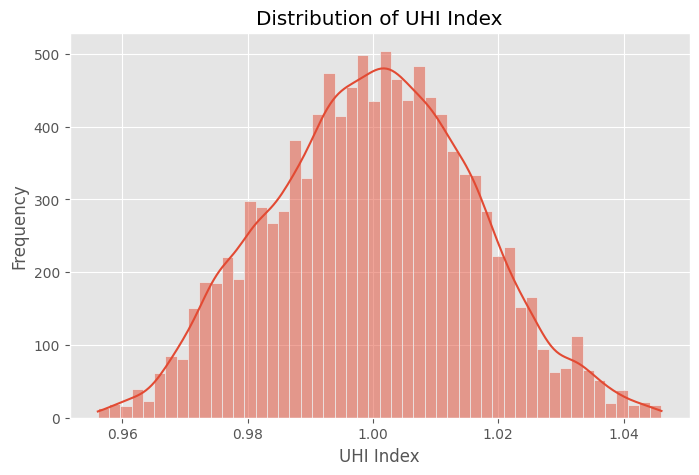

In [13]:
import seaborn as sns

plt.figure(figsize=(8,5))
# print(df.columns)
# Dumbass EY people don't know how to format column headings
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
# print(df.columns)
sns.histplot(df['UHI_Index'], bins=50, kde=True)
plt.title("Distribution of UHI Index")
plt.xlabel("UHI Index")
plt.ylabel("Frequency")
plt.show()

In [14]:
# print(df.columns)
df[['Latitude', 'Longitude']].head()

,Latitude,Longitude
0,40.813107,-73.909167
1,40.813045,-73.909187
2,40.812978,-73.909215
3,40.812908,-73.909242
4,40.812845,-73.909257


In [12]:
import folium
from folium.plugins import HeatMap

map_nyc = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

heat_data = [[row['Latitude'], row['Longitude'], row['UHI_Index']] for index, row in df.iterrows()]
HeatMap(heat_data).add_to(map_nyc)

map_nyc.save("uhi_heatmap.html")

map_nyc


In [ ]:
import geopandas as gpd
from shapely.geometry import Point

building_gdf = gpd.read_file("datasets/Building_Footprint.kml")

df['geometry'] = df.apply(lambda row: Point(row['Longitude'], row['Latitude']), axis=1)
df_gdf = gpd.GeoDataFrame(df, geometry='geometry')

df_gdf['Building_Density'] = df_gdf.geometry.apply(lambda x: building_gdf.within(x.buffer(0.001)).sum())
df_gdf.drop(columns=['geometry'], inplace=True)

df_gdf.head()

,Longitude,Latitude,datetime,UHI_Index,Building_Density
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,1
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,1
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,2
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,2
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,2


NDVI Min: -0.9020461471484545, Max: 0.998703823720026


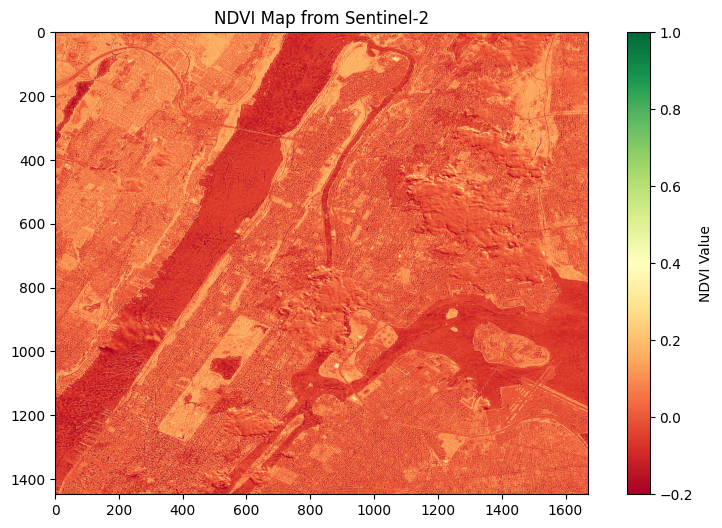

In [ ]:
import rasterio
import numpy as np

with rasterio.open("datasets/S2_sample.tiff") as src:
    sentinel_data = src.read()

    red_band = sentinel_data[2]
    nir_band = sentinel_data[3]

    mask = (nir_band + red_band) > 0
    ndvi = np.full_like(nir_band, np.nan)
    ndvi[mask] = (nir_band[mask] - red_band[mask]) / (nir_band[mask] + red_band[mask])
    
    print(f"NDVI Min: {np.nanmin(ndvi)}, Max: {np.nanmax(ndvi)}")

vmin, vmax = -0.2, 1

plt.figure(figsize=(10, 6))
plt.imshow(ndvi, cmap="RdYlGn", vmin=vmin, vmax=vmax)
plt.colorbar(label="NDVI Value")
plt.title("NDVI Map from Sentinel-2")
plt.show()